# Retrievers

- It is a component in langchain that fetches relevant documents from documents from a data source in a respomse to a user's query
- There are multiple types of retrievers
- All the retrievers in langchain are runnables

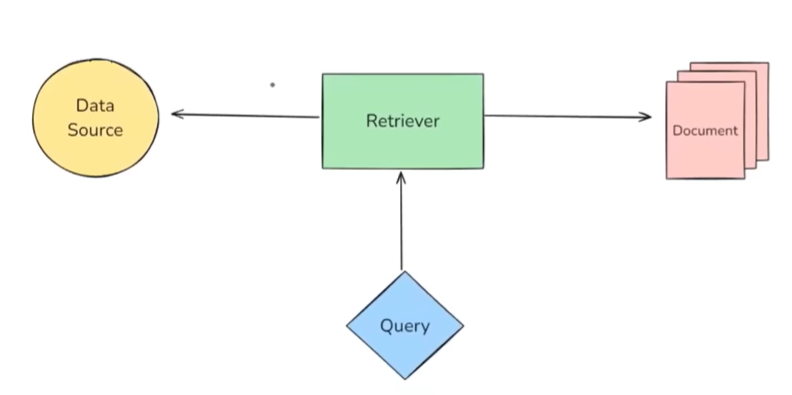

## Wikipedia Retriever
A Wikipedia Retriever is a retriever that queries the Wikipedia API to fetch relevant content for
a given query.

### Working:
1. You give it a query
2. It sends the query to wikipedia's API
3. It retrieves the most relevant articles
4. It returns them as a Langchain Document Objects

In [1]:
from langchain_community.retrievers import WikipediaRetriever

retriever = WikipediaRetriever(top_k_results=2, lang="en")

query = "the geopolitical history of india and pakistan from the perspective of a chinese"
docs = retriever.invoke(query)
print("Retrieved documents:", docs)

Retrieved documents: [Document(metadata={'title': 'Foreign relations of Pakistan', 'summary': "The Islamic Republic of Pakistan emerged as an independent country through the partition of India in August 1947 and was admitted as a United Nations member state in September 1947. It is currently the second-most populous country within the Muslim world, and is also the only Muslim-majority country openly in possession of nuclear weapons. The country shares land borders with India, Iran, Afghanistan, and China.\nThe country has extensive trade relations with the European Union and with several countries globally. As of 2025, Pakistan does not recognize Israel and its ties with India remain frozen since 2019.\nFrom a geopolitical perspective, Pakistan's location is strategically important as it is situated at the crossroads of major maritime and land transit routes between the Middle East and South Asia, while also serving as a bridge between the Arabian Sea and the energy-rich regions of Cen

In [2]:
# Print retrieved content
for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Content:\n{doc.page_content}...")


--- Result 1 ---
Content:
The Islamic Republic of Pakistan emerged as an independent country through the partition of India in August 1947 and was admitted as a United Nations member state in September 1947. It is currently the second-most populous country within the Muslim world, and is also the only Muslim-majority country openly in possession of nuclear weapons. The country shares land borders with India, Iran, Afghanistan, and China.
The country has extensive trade relations with the European Union and with several countries globally. As of 2025, Pakistan does not recognize Israel and its ties with India remain frozen since 2019.
From a geopolitical perspective, Pakistan's location is strategically important as it is situated at the crossroads of major maritime and land transit routes between the Middle East and South Asia, while also serving as a bridge between the Arabian Sea and the energy-rich regions of Central Asia. Since the partition of India, the Kashmir conflict has defi

## Vector Store Retriever
A Vector Store Retriever in LangChain is the most common type of retriever that lets you
search and fetch documents from a vector store based on semantic similarity using vector
embeddings

### Working:
1. You stores your documents in a vector store
2. Each document is converted into a dense vector using a embedding model
3. When user eners a query:
    - It truns into a vector
    - The retriever compares the query vector with the stored vectors
    - It retrieves the top-k most similar ones

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Step 1: Your source documents
documents = [
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Chroma is a vector database optimized for LLM-based search."),
    Document(page_content="Embeddings convert text into high-dimensional vectors."),
    Document(page_content="OpenAI provides powerful embedding models."),
]

# Step 2: Initialize embedding model
embedding_model = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

# Step 3: Create Chroma vector store in memory
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="my_collection"
)

# Step 4: Convert vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

query = "What is Chroma used for?"
results = retriever.invoke(query)

d:\Repos\Gen-AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2179.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
LangChain helps developers build LLM applications easily.


In [6]:
results = vectorstore.similarity_search(query, k=3)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
LangChain helps developers build LLM applications easily.

--- Result 3 ---
Embeddings convert text into high-dimensional vectors.


## MMR
- MMR is an information retrieval algorithm designed to reduce redundancy in the retrieved
results while maintaining high relevance to the query.

### Why MMR:
- In regular similarity search, you may get documents that are:
    1. All very similar to each other
    2. Repeating the same info
    3. Lacking diverse perspective

- MMR avoids that by:
    1. Picking the most relevant document first
    2. Then picking the most relevant & least relevant similar to already selected docs
    3. And so on...

- This helps especially in RAG pipelines where:
    1. You want your context window to contain diverse but still relevant information
    2. Especially usefull when documents are semantically overlaping

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content= "LangChain supports Chroma, FAISS, Pinecone, and more."),
]

# Enable MMR in the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "lambda_mult": 0.5}  # k = top results, lambda_mult = relevance-diversity balance
)

query = "What is langchain?"
results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
The Islamic Republic of Pakistan emerged as an independent country through the partition of India in August 1947 and was admitted as a United Nations member state in September 1947. It is currently the second-most populous country within the Muslim world, and is also the only Muslim-majority country openly in possession of nuclear weapons. The country shares land borders with India, Iran, Afghanistan, and China.
The country has extensive trade relations with the European Union and with several countries globally. As of 2025, Pakistan does not recognize Israel and its ties with India remain frozen since 2019.
From a geopolitical perspective, Pakistan's location is strategically important as it is situated at the crossroads of major maritime and land transit routes between the Middle East and South Asia, while also serving as a bridge between the Arabian Sea and the energy-rich regions of Central Asia. Since the partition of India, the Kashmir conflict has defined the I

## Multi Query Retriever
- LLM generates multiple versions of query
- Pros: Better recall & Handles vague queries
- Cons: More LLM Calls -> Cost

### Working:
1. Takes your original query
2. Uses an LLM to generate multiple semantically versions of that query
3. Performs retrieval for sub-query
4. Combines and duplicates the results

In [12]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langchain_classic.retrievers.multi_query import MultiQueryRetriever

all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

vectorstore = FAISS.from_documents(documents=all_docs, embedding=embedding_model)
similarity_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    llm=ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)
)

query = "How to improve energy levels and maintain balance?"

similarity_results = similarity_retriever.invoke(query)
multiquery_results= multiquery_retriever.invoke(query)

for i, doc in enumerate(similarity_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

print("*"*150)

for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
The solar energy system in modern homes helps balance electricity demand.

--- Result 3 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 4 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 5 ---
Photosynthesis enables plants to produce energy by converting sunlight.
******************************************************************************************************************************************************

--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 3 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 4 ---
The solar energy system in modern homes helps balance elect

## Contextual Compression Retriever
The Contextual Compression Retriever in LangChain is an advanced retriever that improves
retrieval quality by compressing documents after retrieval — keeping only the relevant
content based on the user's query.

### Working:
1. Base retriever retrieves n docs
2. A compressor (LLM) is aplied to each document
3. The compressor keeps only the parts relevant to the query
4. Irrelevant content is discarded

### When to use:
1. Your docs are long & contain mixed information
2. You want to reduce context length for LLMs
3. You need to improve answer accuracy in RAG Pipelines

In [13]:
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
from langchain_core.documents import Document

docs = [
    Document(page_content=(
        """The Grand Canyon is one of the most visited natural wonders in the world.
        Photosynthesis is the process by which green plants convert sunlight into energy.
        Millions of tourists travel to see it every year. The rocks date back millions of years."""
    ), metadata={"source": "Doc1"}),

    Document(page_content=(
        """In medieval Europe, castles were built primarily for defense.
        The chlorophyll in plant cells captures sunlight during photosynthesis.
        Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
    ), metadata={"source": "Doc2"}),

    Document(page_content=(
        """Basketball was invented by Dr. James Naismith in the late 19th century.
        It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
    ), metadata={"source": "Doc3"}),

    Document(page_content=(
        """The history of cinema began in the late 1800s. Silent films were the earliest form.
        Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
        Modern filmmaking involves complex CGI and sound design."""
    ), metadata={"source": "Doc4"})
]
embedding_model = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectorstore = FAISS.from_documents(docs, embedding_model)
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
llm = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)
compressor = LLMChainExtractor.from_llm(llm)

# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=base_retriever,
    base_compressor=compressor
)

# Query the retriever
query = "What is photosynthesis?"
compressed_results = compression_retriever.invoke(query)

for i, doc in enumerate(compressed_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5087.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Result 1 ---
Extracted relevant parts:
Photosynthesis is the process by which green plants convert sunlight into energy.

--- Result 2 ---
The chlorophyll in plant cells captures sunlight during photosynthesis.

--- Result 3 ---
Photosynthesis does not occur in animal cells.


### Other Retrievers
1. BM25Retriever
2. ParentDocumentRetriever
3. SelfQuerbRetriever
4. MultivectorRetriever
5. ArxivRetriever
6. TimeWeightedVectorRetriever
7. EnsembleRetriever